In [1]:
import numpy as np
import random
from functools import reduce
from itertools import chain, combinations, product, repeat
from scipy import linalg, sparse
import matplotlib.pyplot as plt
import os
from scipy.stats import unitary_group
import time 
import rcFun


In [2]:
Id2 = np.array([[1,0],[0,1]], dtype = 'complex128')
S_X = np.array([[0,1],[1,0]], dtype = 'complex128')
S_Y = np.array([[0,-1j],[1j,0]], dtype = 'complex128')
S_Z = np.array([[1,0],[0,-1]], dtype = 'complex128')
paulis = [Id2, S_X, S_Y, S_Z]/np.sqrt(2)
basis4by4=np.kron(paulis,paulis)

S_plus = (S_X+1j*S_Y)/2
S_minus = (S_X-1j*S_Y)/2

In [6]:
p = 0
N = 8
jumpOp_global = S_Z
r = 0.1
ens_N = 1

t_total = 400
dt=5
steps_N = int(t_total/dt)


S1List = np.zeros([ens_N,steps_N])
S2List = np.zeros([ens_N,steps_N])
StotList = np.zeros([ens_N,steps_N])
mutualInfoList = np.zeros([ens_N,steps_N])
purityList = np.zeros([ens_N,steps_N])
finalStateList = {}



qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

# Pure state start:
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
initR = state0rho

print('jumpOp =', jumpOp_global, ',Nqubit=', N,  ', p =', p,', rate = ', r, ', total steps=', steps_N, 'initRho=', initR )
for j in range(ens_N):
    startTime = time.time()
    S1List[j,:], S2List[j,:], StotList[j,:], mutualInfoList[j,:], purityList[j,:], finalStateList[j] = rcFun.combinedRoutine(initRho = initR,
                                Nqubit = N,
                                rate = r,
                                probMsm = p,
                                dt = dt ,
                                jumpOp = jumpOp_global,
                                steps = steps_N,
                                debug = False)
    
    print('run time for trajectory ', str(j), ' =', time.time()-startTime, flush=True)


jumpOp = [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]] ,Nqubit= 8 , p = 0 , rate =  0.1 , total steps= 80 initRho= [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]
run time for trajectory  0  = 62.59651303291321


1.734723475976807e-18


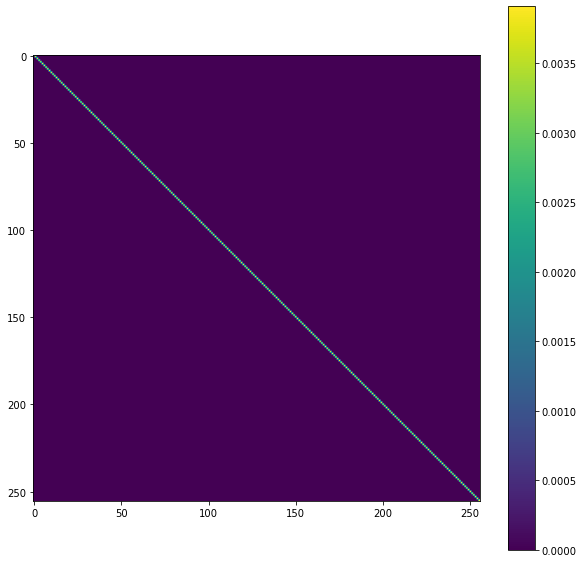

In [25]:
finalStateList[0].toarray().round(5)


plt.figure(figsize=[10,10])    
plt.imshow(np.real(finalStateList[0].toarray().round(5)))
plt.colorbar()

#print(np.diag(finalStateList[0].toarray().round(5)))
print(np.std(np.diag(finalStateList[0].toarray().round(5))))
    

In [26]:
p = 0
N = 8
jumpOp_global = S_minus
r = 0.1
ens_N = 1

t_total = 400
dt=5
steps_N = int(t_total/dt)


S1List = np.zeros([ens_N,steps_N])
S2List = np.zeros([ens_N,steps_N])
StotList = np.zeros([ens_N,steps_N])
mutualInfoList = np.zeros([ens_N,steps_N])
purityList = np.zeros([ens_N,steps_N])
finalStateList = {}



qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

# Pure state start:
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
initR = state0rho

print('jumpOp =', jumpOp_global, ',Nqubit=', N,  ', p =', p,', rate = ', r, ', total steps=', steps_N, 'initRho=', initR )
for j in range(ens_N):
    startTime = time.time()
    S1List[j,:], S2List[j,:], StotList[j,:], mutualInfoList[j,:], purityList[j,:], finalStateList[j] = rcFun.combinedRoutine(initRho = initR,
                                Nqubit = N,
                                rate = r,
                                probMsm = p,
                                dt = dt ,
                                jumpOp = jumpOp_global,
                                steps = steps_N,
                                debug = False)
    
    print('run time for trajectory ', str(j), ' =', time.time()-startTime, flush=True)


jumpOp = [[0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j]] ,Nqubit= 8 , p = 0 , rate =  0.1 , total steps= 80 initRho= [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]
run time for trajectory  0  = 69.27483201026917


0.0010142185423807752


Text(0, 0.5, 'purity')

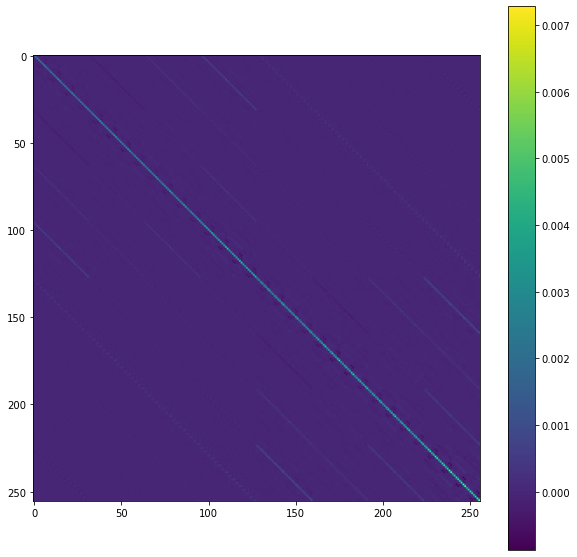

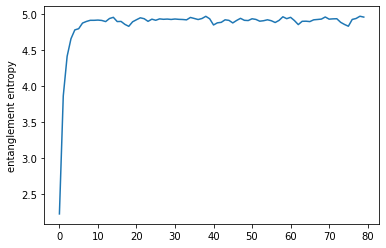

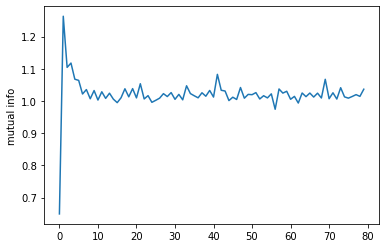

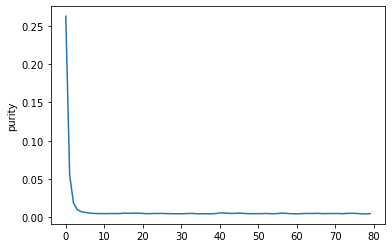

In [32]:
finalStateList[0].toarray().round(5)


plt.figure(figsize=[10,10])    
plt.imshow(np.real(finalStateList[0].toarray().round(5)))
plt.colorbar()

#print(np.diag(finalStateList[0].toarray().round(5)))
print(np.std(np.diag(finalStateList[0].toarray().round(5))))

plt.figure()
plt.plot(S1List[0,:])
plt.ylabel('entanglement entropy')


plt.figure()
plt.plot(mutualInfoList[0,:])
plt.ylabel('mutual info')


plt.figure()
plt.plot(purityList[0,:])
plt.ylabel('purity')
    

In [40]:
p = 0.5
N = 8
jumpOp_global = S_minus
r = 10
ens_N = 1

t_total = 400
dt=5
steps_N = int(t_total/dt)


S1List = np.zeros([ens_N,steps_N])
S2List = np.zeros([ens_N,steps_N])
StotList = np.zeros([ens_N,steps_N])
mutualInfoList = np.zeros([ens_N,steps_N])
purityList = np.zeros([ens_N,steps_N])
finalStateList = {}



qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

# Pure state start:
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
initR = state0rho

print('jumpOp =', jumpOp_global, ',Nqubit=', N,  ', p =', p,', rate = ', r, ', total steps=', steps_N, 'initRho=', initR )
for j in range(ens_N):
    startTime = time.time()
    S1List[j,:], S2List[j,:], StotList[j,:], mutualInfoList[j,:], purityList[j,:], finalStateList[j] = rcFun.combinedRoutine(initRho = initR,
                                Nqubit = N,
                                rate = r,
                                probMsm = p,
                                dt = dt ,
                                jumpOp = jumpOp_global,
                                steps = steps_N,
                                debug = False)
    
    print('run time for trajectory ', str(j), ' =', time.time()-startTime, flush=True)


jumpOp = [[0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j]] ,Nqubit= 8 , p = 0.5 , rate =  10 , total steps= 80 initRho= [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]
run time for trajectory  0  = 84.72109389305115


[0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    

Text(0, 0.5, 'purity')

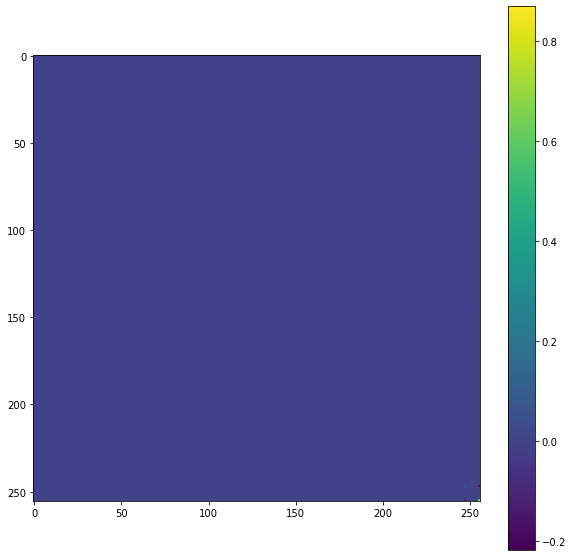

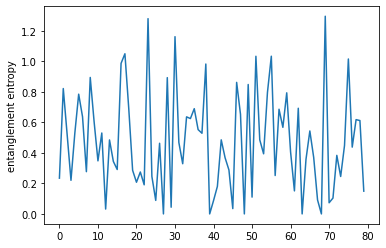

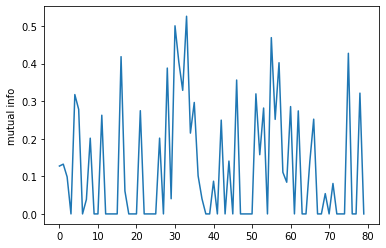

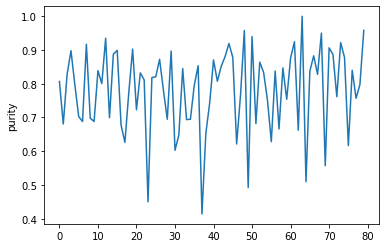

In [42]:
finalStateList[0].toarray().round(5)


plt.figure(figsize=[10,10])    
plt.imshow(np.real(finalStateList[0].toarray().round(5)))
plt.colorbar()

print(np.diag(finalStateList[0].toarray().round(5)))
print(np.std(np.diag(finalStateList[0].toarray().round(5))))

plt.figure()
plt.plot(S1List[0,:])
plt.ylabel('entanglement entropy')


plt.figure()
plt.plot(mutualInfoList[0,:])
plt.ylabel('mutual info')


plt.figure()
plt.plot(purityList[0,:])
plt.ylabel('purity')
    

In [47]:
np.sort(np.triu(finalStateList[0].toarray().round(5)).flatten())

array([-0.21728+0.21396j,  0.     +0.j     ,  0.     +0.j     , ...,
        0.     +0.j     ,  0.1311 -0.j     ,  0.8689 +0.j     ])

[[ 0.0000e+00-0.000e+00j -0.0000e+00+0.000e+00j -0.0000e+00+0.000e+00j
  ... -2.0000e-05+0.000e+00j -1.0000e-05-2.000e-05j
   3.0000e-05-9.000e-05j]
 [-0.0000e+00-0.000e+00j  0.0000e+00-0.000e+00j  0.0000e+00+0.000e+00j
  ...  0.0000e+00+4.000e-05j -3.0000e-05+1.000e-05j
  -1.3000e-04-5.000e-05j]
 [-0.0000e+00-0.000e+00j  0.0000e+00-0.000e+00j  0.0000e+00+0.000e+00j
  ...  3.0000e-05+3.000e-05j -3.0000e-05+4.000e-05j
  -1.9000e-04+3.000e-05j]
 ...
 [-2.0000e-05-0.000e+00j  0.0000e+00-4.000e-05j  3.0000e-05-3.000e-05j
  ...  3.5820e-02+0.000e+00j  5.7400e-03+2.588e-02j
  -5.8280e-02+9.687e-02j]
 [-1.0000e-05+2.000e-05j -3.0000e-05-1.000e-05j -3.0000e-05-4.000e-05j
  ...  5.7400e-03-2.588e-02j  3.5040e-02+0.000e+00j
   7.5310e-02+7.156e-02j]
 [ 3.0000e-05+9.000e-05j -1.3000e-04+5.000e-05j -1.9000e-04-3.000e-05j
  ... -5.8280e-02-9.687e-02j  7.5310e-02-7.156e-02j
   4.4308e-01-0.000e+00j]]
0.028914363931740714


Text(0, 0.5, 'purity')

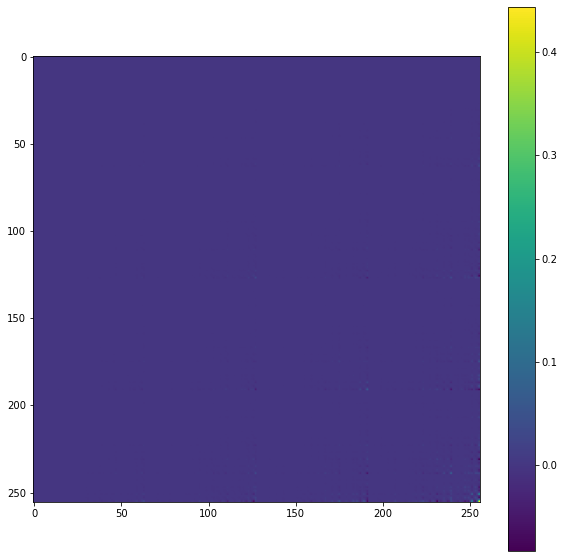

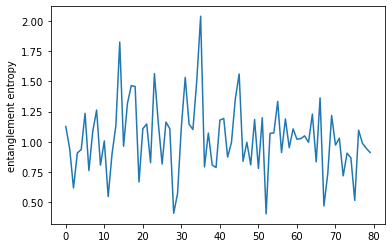

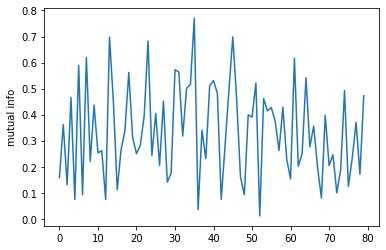

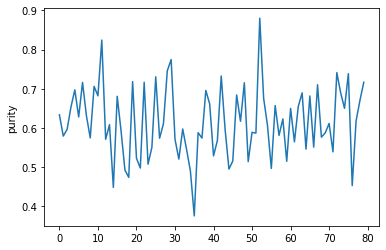

In [39]:
finalStateList[0].toarray().round(5)


plt.figure(figsize=[10,10])    
plt.imshow(np.real(finalStateList[0].toarray().round(5)))
plt.colorbar()

print(finalStateList[0].toarray().round(5))
print(np.std(np.diag(finalStateList[0].toarray().round(5))))

plt.figure()
plt.plot(S1List[0,:])
plt.ylabel('entanglement entropy')


plt.figure()
plt.plot(mutualInfoList[0,:])
plt.ylabel('mutual info')


plt.figure()
plt.plot(purityList[0,:])
plt.ylabel('purity')
    